# Post-Selected vs Flattened-H Frobenius Comparison

Compare the half-filled OW flattened-H covariance against the deterministic post-selected Markov covariance at cycle $$T$$.

This notebook uses `classA_U1FGTN_gpu.run_markov_circuit(...)` for the circuit dynamics and stores full covariance history (`G_history=True`) so that each configured $$T$$ can be probed directly.

## Setup

In [1]:
from __future__ import annotations

import gc
import importlib
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager

try:
    import torch
except ImportError:
    torch = None


def find_repo_root(start: Path) -> Path:
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "REPO_POLICY.md").exists() and (candidate / "src" / "fgtn" / "classA_U1FGTN_gpu.py").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from {start}")


ROOT = find_repo_root(Path.cwd())
NOTEBOOK_ANALYSIS_DIR = ROOT / "notebooks" / "flattened_hamiltonian_analysis"
DATA_DIR = NOTEBOOK_ANALYSIS_DIR / "data"
FIG_DIR = NOTEBOOK_ANALYSIS_DIR / "figures" / "postselected_flattened_frobenius"
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

classA_U1FGTN_module = importlib.import_module("fgtn.classA_U1FGTN")
classA_U1FGTN_gpu_module = importlib.import_module("fgtn.classA_U1FGTN_gpu")
importlib.reload(classA_U1FGTN_module)
importlib.reload(classA_U1FGTN_gpu_module)
classA_U1FGTN = classA_U1FGTN_module.classA_U1FGTN
classA_U1FGTN_gpu = classA_U1FGTN_gpu_module.classA_U1FGTN_gpu

CANONICAL_DYNAMICS_ENTRY_POINT = "classA_U1FGTN_gpu.run_markov_circuit"

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if "CMU Sans Serif" in available_fonts:
    plt.rcParams["font.family"] = "CMU Sans Serif"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
    print("CMU Sans Serif not found; using DejaVu Sans")

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "lines.linewidth": 1.2,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.autolayout": False,
})
np.set_printoptions(precision=6, suppress=True)

if torch is not None:
    print(f"torch: {torch.__version__}")
    print(f"cuda available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"cuda device: {torch.cuda.get_device_name(0)}")
print(f"ROOT = {ROOT}")
print(f"NOTEBOOK_ANALYSIS_DIR = {NOTEBOOK_ANALYSIS_DIR}")
print(f"canonical dynamics entry point = {CANONICAL_DYNAMICS_ENTRY_POINT}")

torch: 2.8.0+cu128
cuda available: False
ROOT = /home/abhuiyan/class_A_fermionic_adaptive_circuit
NOTEBOOK_ANALYSIS_DIR = /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis
canonical dynamics entry point = classA_U1FGTN_gpu.run_markov_circuit


## Configuration

In [2]:
# ------------------------------
# Scan controls
# ------------------------------
ALPHA_1 = 1.0
ALPHA_2_VALUES = [30.0]
NX = 16
NY = 20
DW = True
NSHELL_VALUES = [1]
DW_TRUNCATION_OPTIONS = [False, True]
TRIAL_ORBITAL = "X"
TRIV_REGION_LOCAL_MODE = False

T_VALUES = list(range(41))
CYCLES = 40

INIT_MODE = "default"
N_A = 0.5
SEQUENCE = "raster_y"
DTYPE = "complex128"
BACKEND = "local"
DEVICE = "cpu"
BATCH_SIZE = 1
CPU_THREADS = 10
PROGRESS = True
RUN_SCAN = True
KEEP_RAW_RESULTS = False
SAVE_SUMMARY = True
SAVE_FIGURES = True

if torch is not None:
    torch.set_num_threads(CPU_THREADS)
    try:
        torch.set_num_interop_threads(max(1, min(2, CPU_THREADS)))
    except RuntimeError:
        # Interop threads can only be set before parallel work starts in a process.
        pass
    print(f"torch num threads: {torch.get_num_threads()}")

SUMMARY_STEM = "postselected_flattened_frobenius_N16x20_alpha2_30_nshell1"
SUMMARY_CSV = DATA_DIR / f"{SUMMARY_STEM}.csv"
SUMMARY_PKL = DATA_DIR / f"{SUMMARY_STEM}.pkl"
SUMMARY_PARQUET = DATA_DIR / f"{SUMMARY_STEM}.parquet"

# Tiny validation path used by nbconvert smoke tests.
if os.environ.get("FROBENIUS_SMOKE_TEST") == "1":
    ALPHA_2_VALUES = [2.0]
    NX = 4
    NY = 6
    NSHELL_VALUES = [1]
    DW_TRUNCATION_OPTIONS = [True]
    T_VALUES = [0, 1, 2]
    CYCLES = 2
    DEVICE = "cuda:0" if (torch is not None and torch.cuda.is_available()) else "cpu"
    PROGRESS = False
    SAVE_SUMMARY = False
    SAVE_FIGURES = False
    if torch is None:
        RUN_SCAN = False
        print("PyTorch is not available; smoke execution will validate notebook structure without running dynamics.")
    SUMMARY_STEM = "postselected_flattened_frobenius_summary_smoke"
    SUMMARY_CSV = DATA_DIR / f"{SUMMARY_STEM}.csv"
    SUMMARY_PKL = DATA_DIR / f"{SUMMARY_STEM}.pkl"
    SUMMARY_PARQUET = DATA_DIR / f"{SUMMARY_STEM}.parquet"

T_VALUES = [int(t) for t in T_VALUES]
CYCLES = int(CYCLES)
if min(T_VALUES) < 0 or max(T_VALUES) > CYCLES:
    raise ValueError(f"T_VALUES must lie in 0..CYCLES; got T_VALUES={T_VALUES}, CYCLES={CYCLES}")
if CYCLES != max(T_VALUES):
    print(f"CYCLES={CYCLES} exceeds max(T_VALUES)={max(T_VALUES)}; the full history will include unused cycles.")

N_LAYER = 2 * NX * NY
HALF_FILLING = N_LAYER // 2
EST_HISTORY_BYTES = (CYCLES + 1) * N_LAYER * N_LAYER * np.dtype(np.complex128).itemsize

config = {
    "Nx": NX,
    "Ny": NY,
    "N_layer": N_LAYER,
    "half_filling": HALF_FILLING,
    "DW": DW,
    "alpha_1": ALPHA_1,
    "alpha_2_values": ALPHA_2_VALUES,
    "nshell_values": NSHELL_VALUES,
    "dw_truncation_options": DW_TRUNCATION_OPTIONS,
    "cycles": CYCLES,
    "T_values": T_VALUES,
    "trial_orbital": TRIAL_ORBITAL,
    "triv_region_local_mode": TRIV_REGION_LOCAL_MODE,
    "init_mode": INIT_MODE,
    "n_a": N_A,
    "sequence": SEQUENCE,
    "device": DEVICE,
    "dtype": DTYPE,
    "backend": BACKEND,
    "cpu_threads": CPU_THREADS,
    "canonical_dynamics_entry_point": CANONICAL_DYNAMICS_ENTRY_POINT,
    "estimated_history_bytes_per_run": int(EST_HISTORY_BYTES),
}
display(pd.DataFrame([config]))
print(f"Estimated full-history covariance storage per run: {EST_HISTORY_BYTES / 1024**3:.3f} GiB")

torch num threads: 10


,Nx,Ny,N_layer,half_filling,DW,alpha_1,alpha_2_values,nshell_values,dw_truncation_options,cycles,...,triv_region_local_mode,init_mode,n_a,sequence,device,dtype,backend,cpu_threads,canonical_dynamics_entry_point,estimated_history_bytes_per_run
0,16,20,640,320,True,1.0,[30.0],[1],"[False, True]",40,...,False,default,0.5,raster_y,cpu,complex128,local,10,classA_U1FGTN_gpu.run_markov_circuit,268697600


Estimated full-history covariance storage per run: 0.250 GiB


## Helpers

In [3]:
def nshell_label(nshell) -> str:
    if nshell is None:
        return "None"
    value = float(nshell)
    return str(int(value)) if value.is_integer() else str(value)


def frobenius_norm(matrix) -> float:
    matrix = np.asarray(matrix)
    return float(np.linalg.norm(matrix, ord="fro"))


def hermiticity_norm(matrix) -> float:
    matrix = np.asarray(matrix, dtype=np.complex128)
    return frobenius_norm(matrix - matrix.conj().T)


def matrix_diagnostics(matrix, *, prefix: str) -> dict:
    matrix = np.asarray(matrix, dtype=np.complex128)
    return {
        f"{prefix}_finite": bool(np.all(np.isfinite(matrix))),
        f"{prefix}_hermiticity_fro": hermiticity_norm(matrix),
        f"{prefix}_fro": frobenius_norm(matrix),
        f"{prefix}_trace_real": float(np.real(np.trace(matrix))),
        f"{prefix}_trace_imag_abs": float(abs(np.imag(np.trace(matrix)))),
    }


def build_flattened_state(model, *, trial_orbital="X", dw_truncation=False) -> dict:
    """Build the half-filled OW flattened-H covariance using the alpha-sweep convention."""
    nlayer = 2 * model.Nx * model.Ny
    model.construct_OW_projectors(
        nshell=model.nshell,
        DW=model.DW,
        trial_orbitals=trial_orbital,
        dw_truncation=dw_truncation,
    )

    WA_p = model.WF_Ap.reshape(nlayer, -1)
    WB_p = model.WF_Bp.reshape(nlayer, -1)
    WA_m = model.WF_Am.reshape(nlayer, -1)
    WB_m = model.WF_Bm.reshape(nlayer, -1)

    H_flat = WA_p @ WA_p.conj().T + WB_p @ WB_p.conj().T - WA_m @ WA_m.conj().T - WB_m @ WB_m.conj().T
    H_flat = 0.5 * (H_flat + H_flat.conj().T)

    evals, evecs = np.linalg.eigh(H_flat)
    neg_count = int(np.count_nonzero(evals < 0.0))
    occ_indices = np.argsort(evals)[: nlayer // 2]
    U_occ = evecs[:, occ_indices]
    P_occ = U_occ @ U_occ.conj().T
    C_ow = 2.0 * P_occ.conj() - np.eye(nlayer, dtype=np.complex128)

    sorted_abs = np.sort(np.abs(np.asarray(evals, dtype=np.float64)))
    return {
        "H_flat": H_flat,
        "evals": np.real_if_close(evals),
        "C_ow": C_ow,
        "neg_count": neg_count,
        "occ_count": int(len(occ_indices)),
        "exact_half_fill_from_negative_evals": bool(neg_count == nlayer // 2),
        "spectral_gap_abs_min": float(sorted_abs[0]),
        "spectral_gap_half_fill": float(evals[occ_indices[-1] + 1] - evals[occ_indices[-1]]) if occ_indices[-1] + 1 < len(evals) else np.nan,
        "mean_abs_eval": float(np.mean(np.abs(evals))),
    }


def run_postselected_history(*, nx, ny, nshell, alpha_1, alpha_2, dw_truncation) -> dict:
    model = classA_U1FGTN_gpu(
        Nx=nx,
        Ny=ny,
        DW=True,
        nshell=nshell,
        filling_frac=0.5,
        alpha_1=alpha_1,
        alpha_2=alpha_2,
        trial_orbitals=TRIAL_ORBITAL,
        dw_truncation=dw_truncation,
        triv_region_local_mode=TRIV_REGION_LOCAL_MODE,
        device=DEVICE,
        dtype=DTYPE,
        backend=BACKEND,
    )
    result = model.run_markov_circuit(
        G_history=True,
        progress=PROGRESS,
        cycles=CYCLES,
        postselect=True,
        perfect_correction=False,
        samples=1,
        init_mode=INIT_MODE,
        save=False,
        save_init=True,
        n_a=N_A,
        sequence=SEQUENCE,
        batch_size=BATCH_SIZE,
        return_data=True,
    )
    result["canonical_dynamics_entry_point"] = CANONICAL_DYNAMICS_ENTRY_POINT
    return result


def comparison_rows(*, C_ow, flat_state, G_hist, nshell, alpha_2, dw_truncation, elapsed_seconds) -> list[dict]:
    expected_shape = (N_LAYER, N_LAYER)
    if C_ow.shape != expected_shape:
        raise ValueError(f"C_ow shape mismatch: expected {expected_shape}, got {C_ow.shape}")
    if G_hist.shape != (1, CYCLES + 1, N_LAYER, N_LAYER):
        raise ValueError(f"G_hist shape mismatch: expected {(1, CYCLES + 1, N_LAYER, N_LAYER)}, got {G_hist.shape}")

    rows = []
    C_norm = frobenius_norm(C_ow)
    C_diag = matrix_diagnostics(C_ow, prefix="flattened")
    for T in T_VALUES:
        G_T = np.asarray(G_hist[0, int(T)], dtype=np.complex128)
        if G_T.shape != C_ow.shape:
            raise ValueError(f"G(T) shape mismatch at T={T}: expected {C_ow.shape}, got {G_T.shape}")
        diff = G_T - C_ow
        diff_norm = frobenius_norm(diff)
        row = {
            "Nx": int(NX),
            "Ny": int(NY),
            "N_layer": int(N_LAYER),
            "alpha_1": float(ALPHA_1),
            "alpha_2": float(alpha_2),
            "DW": bool(DW),
            "nshell": nshell_label(nshell),
            "nshell_value": np.nan if nshell is None else float(nshell),
            "dw_truncation": bool(dw_truncation),
            "triv_region_local_mode": bool(TRIV_REGION_LOCAL_MODE),
            "trial_orbital": TRIAL_ORBITAL,
            "cycle_T": int(T),
            "cycles_run": int(CYCLES),
            "fro_norm": diff_norm,
            "fro_norm_normalized": float(diff_norm / np.sqrt(N_LAYER)),
            "fro_norm_relative_to_flattened": float(diff_norm / C_norm) if C_norm > 0.0 else np.nan,
            "flattened_occ_count": int(flat_state["occ_count"]),
            "flattened_neg_count": int(flat_state["neg_count"]),
            "flattened_exact_half_fill_from_negative_evals": bool(flat_state["exact_half_fill_from_negative_evals"]),
            "flattened_spectral_gap_abs_min": float(flat_state["spectral_gap_abs_min"]),
            "flattened_spectral_gap_half_fill": float(flat_state["spectral_gap_half_fill"]),
            "flattened_mean_abs_eval": float(flat_state["mean_abs_eval"]),
            "elapsed_seconds_for_config": float(elapsed_seconds),
            "canonical_dynamics_entry_point": CANONICAL_DYNAMICS_ENTRY_POINT,
            "device": DEVICE,
            "dtype": DTYPE,
            "backend": BACKEND,
            "sequence": SEQUENCE,
            "init_mode": INIT_MODE,
        }
        row.update(C_diag)
        row.update(matrix_diagnostics(G_T, prefix="postselected"))
        rows.append(row)
    return rows


def save_summary_tables(df: pd.DataFrame) -> None:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(SUMMARY_CSV, index=False)
    df.to_pickle(SUMMARY_PKL)
    try:
        df.to_parquet(SUMMARY_PARQUET, index=False)
    except Exception as exc:
        print(f"Skipping parquet export: {exc}")
    print(f"Saved summary CSV: {SUMMARY_CSV}")
    print(f"Saved summary PKL: {SUMMARY_PKL}")


def selected_metric_label(metric: str) -> str:
    labels = {
        "fro_norm": r"$||G(T)-C_{ow}||_F$",
        "fro_norm_normalized": r"$||G(T)-C_{ow}||_F / \sqrt{N_{layer}}$",
        "fro_norm_relative_to_flattened": r"$||G(T)-C_{ow}||_F / ||C_{ow}||_F$",
    }
    return labels.get(metric, metric)


def save_figure(fig, filename: str, *, enabled: bool = True) -> None:
    if enabled:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        path = FIG_DIR / filename
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {path}")

## Run Comparison

In [4]:
summary_rows = []
raw_results = {} if KEEP_RAW_RESULTS else None

if RUN_SCAN and torch is None:
    raise ImportError("PyTorch is required to run post-selected dynamics with classA_U1FGTN_gpu.")

if not RUN_SCAN:
    display(Markdown("`RUN_SCAN=False`; set it to `True` in the configuration cell to run the comparison."))
    summary_df = pd.DataFrame()
else:
    run_start = time.time()
    for nshell in NSHELL_VALUES:
        for dw_truncation in DW_TRUNCATION_OPTIONS:
            for alpha_2 in ALPHA_2_VALUES:
                label = f"N{NX}x{NY} nshell={nshell_label(nshell)} dw_truncation={dw_truncation} alpha_2={alpha_2}"
                print("=" * 100)
                print(label)
                print("=" * 100)
                config_start = time.time()

                flat_model = classA_U1FGTN(
                    NX,
                    NY,
                    DW=DW,
                    nshell=nshell,
                    filling_frac=0.5,
                    alpha_1=ALPHA_1,
                    alpha_2=alpha_2,
                )
                flat_state = build_flattened_state(
                    flat_model,
                    trial_orbital=TRIAL_ORBITAL,
                    dw_truncation=dw_truncation,
                )
                C_ow = np.asarray(flat_state["C_ow"], dtype=np.complex128)

                markov_result = run_postselected_history(
                    nx=NX,
                    ny=NY,
                    nshell=nshell,
                    alpha_1=ALPHA_1,
                    alpha_2=alpha_2,
                    dw_truncation=dw_truncation,
                )
                if markov_result.get("canonical_dynamics_entry_point") != CANONICAL_DYNAMICS_ENTRY_POINT:
                    raise RuntimeError("Canonical dynamics entry point metadata mismatch")
                G_hist = np.asarray(markov_result["G_hist"], dtype=np.complex128)
                elapsed = time.time() - config_start

                summary_rows.extend(
                    comparison_rows(
                        C_ow=C_ow,
                        flat_state=flat_state,
                        G_hist=G_hist,
                        nshell=nshell,
                        alpha_2=alpha_2,
                        dw_truncation=dw_truncation,
                        elapsed_seconds=elapsed,
                    )
                )

                if KEEP_RAW_RESULTS:
                    raw_results[(nshell_label(nshell), bool(dw_truncation), float(alpha_2))] = {
                        "flat_state": flat_state,
                        "markov_result": markov_result,
                    }

                del flat_model, flat_state, C_ow, markov_result, G_hist
                gc.collect()
                if torch is not None and torch.cuda.is_available():
                    torch.cuda.empty_cache()

    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["nshell", "dw_truncation", "alpha_2", "cycle_T"]
    ).reset_index(drop=True)
    print(f"Completed {len(summary_df)} rows in {(time.time() - run_start) / 60.0:.2f} min")
    if SAVE_SUMMARY:
        save_summary_tables(summary_df)

summary_df

N16x20 nshell=1 dw_truncation=False alpha_2=30.0
DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------


[info] constructed Wannier projectors nshell=1 dw_truncation=False backend=local device=cpu dtype=torch.complex128


Markov GPU batches:   0%|          | 0/1 [00:00<?, ?sample/s]

[progress] batch 1/1 samples 0:1


Markov GPU batches: 100%|██████████| 1/1 [00:55<00:00, 55.90s/sample]

...

[progress] batch 1/1 samples 0:1


Markov GPU batches: 100%|██████████| 1/1 [00:54<00:00, 54.00s/sample]

Markov GPU batches: 100%|██████████| 1/1 [00:54<00:00, 54.00s/sample]

Completed 82 rows in 1.86 min
Saved summary CSV: /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/postselected_flattened_frobenius_N16x20_alpha2_30_nshell1.csv
Saved summary PKL: /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/postselected_flattened_frobenius_N16x20_alpha2_30_nshell1.pkl


,Nx,Ny,N_layer,alpha_1,alpha_2,DW,nshell,nshell_value,dw_truncation,triv_region_local_mode,...,flattened_finite,flattened_hermiticity_fro,flattened_fro,flattened_trace_real,flattened_trace_imag_abs,postselected_finite,postselected_hermiticity_fro,postselected_fro,postselected_trace_real,postselected_trace_imag_abs
0,16,20,640,1.0,30.0,True,1,1.0,False,False,...,True,0.0,25.298221,-1.385558e-13,0.0,True,0.0,25.298221,1.296740e-13,0.0
1,16,20,640,1.0,30.0,True,1,1.0,False,False,...,True,0.0,25.298221,-1.385558e-13,0.0,True,0.0,25.298221,1.296740e-13,0.0
2,16,20,640,1.0,30.0,True,1,1.0,False,False,...,True,0.0,25.298221,-1.385558e-13,0.0,True,0.0,25.298221,1.296740e-13,0.0
3,16,20,640,1.0,30.0,True,1,1.0,False,False,...,True,0.0,25.298221,-1.385558e-13,0.0,True,0.0,25.298221,1.296740e-13,0.0
4,16,20,640,1.0,30.0,True,1,1.0,False,False,...,True,0.0,25.298221,-1.385558e-13,0.0,True,0.0,25.298221,1.296740e-13,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,16,20,640,1.0,30.0,True,1,1.0,True,False,...,True,0.0,25.298221,8.881784e-16,0.0,True,0.0,25.298221,9.148238e-14,0.0
78,16,20,640,1.0,30.0,True,1,1.0,True,False,...,True,0.0,25.298221,8.881784e-16,0.0,True,0.0,25.298221,9.148238e-14,0.0
79,16,20,640,1.0,30.0,True,1,1.0,True,False,...,True,0.0,25.298221,8.881784e-16,0.0,True,0.0,25.298221,9.148238e-14,0.0
80,16,20,640,1.0,30.0,True,1,1.0,True,False,...,True,0.0,25.298221,8.881784e-16,0.0,True,0.0,25.298221,9.148238e-14,0.0


## Validation Summary

In [5]:
if summary_df.empty:
    display(Markdown("No rows to validate."))
else:
    if not (summary_df["canonical_dynamics_entry_point"] == CANONICAL_DYNAMICS_ENTRY_POINT).all():
        raise RuntimeError("At least one row did not record the canonical GPU dynamics entry point.")
    if not summary_df["flattened_finite"].all():
        raise RuntimeError("At least one flattened covariance contains non-finite entries.")
    if not summary_df["postselected_finite"].all():
        raise RuntimeError("At least one post-selected covariance contains non-finite entries.")

    validation_cols = [
        "nshell",
        "dw_truncation",
        "alpha_2",
        "cycle_T",
        "fro_norm",
        "fro_norm_normalized",
        "fro_norm_relative_to_flattened",
        "flattened_hermiticity_fro",
        "postselected_hermiticity_fro",
        "flattened_exact_half_fill_from_negative_evals",
        "canonical_dynamics_entry_point",
    ]
    display(summary_df[validation_cols])

,nshell,dw_truncation,alpha_2,cycle_T,fro_norm,fro_norm_normalized,fro_norm_relative_to_flattened,flattened_hermiticity_fro,postselected_hermiticity_fro,flattened_exact_half_fill_from_negative_evals,canonical_dynamics_entry_point
0,1,False,30.0,0,19.046324,0.752872,0.752872,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
1,1,False,30.0,1,19.046324,0.752872,0.752872,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
2,1,False,30.0,2,19.046324,0.752872,0.752872,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
3,1,False,30.0,3,19.046324,0.752872,0.752872,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
4,1,False,30.0,4,19.046324,0.752872,0.752872,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
...,...,...,...,...,...,...,...,...,...,...,...
77,1,True,30.0,36,18.240457,0.721017,0.721017,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
78,1,True,30.0,37,18.240457,0.721017,0.721017,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
79,1,True,30.0,38,18.240457,0.721017,0.721017,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit
80,1,True,30.0,39,18.240457,0.721017,0.721017,0.0,0.0,True,classA_U1FGTN_gpu.run_markov_circuit


## Figure: Frobenius Distance vs Cycle

Saved figure: /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/figures/postselected_flattened_frobenius/frobenius_vs_cycle_N16x20_alpha2_30_nshell1.png


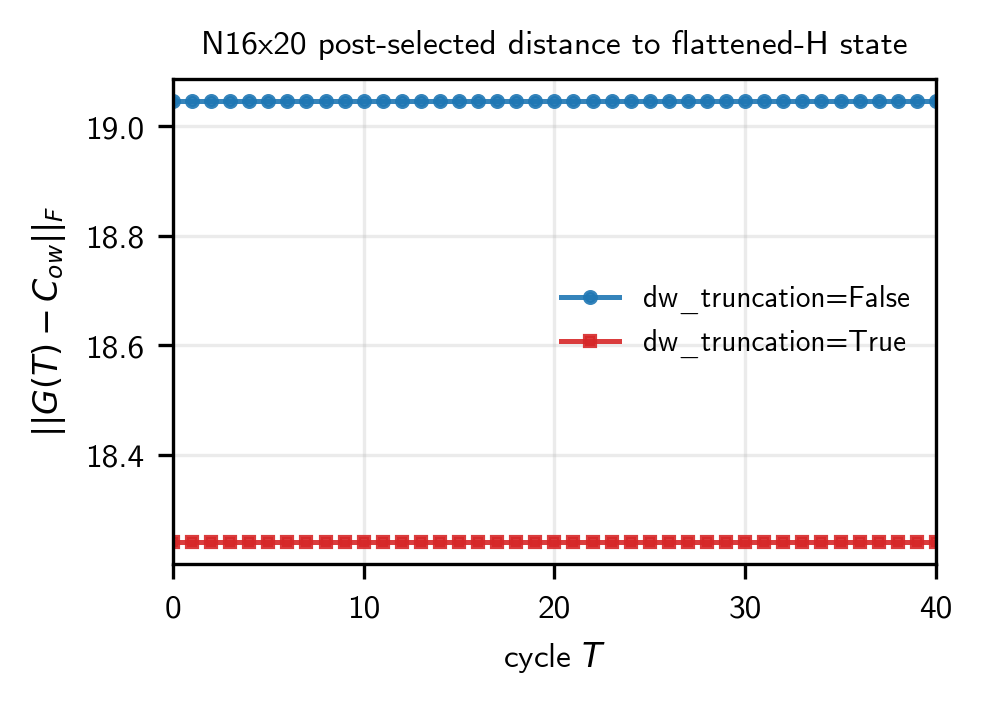

In [6]:
# ------------------------------
# Plot controls
# ------------------------------
PLOT_METRIC = "fro_norm"
PLOT_NSHELL_FILTER = "1"
PLOT_ALPHA_2_FILTER = 30.0
PLOT_DW_TRUNCATION_FILTER = None
FIGSIZE = (3.375, 2.45)
TITLE = r"N16x20 post-selected distance to flattened-H state"
XLABEL = r"cycle $T$"
YLABEL = selected_metric_label(PLOT_METRIC)
LEGEND_LOC = "best"
X_SCALE = "linear"
Y_SCALE = "linear"
X_LIMITS = (0, 40)
Y_LIMITS = None
COLORS = {False: "tab:blue", True: "tab:red"}
MARKERS = {False: "o", True: "s"}
SAVE_THIS_FIGURE = SAVE_FIGURES
FIGURE_NAME = "frobenius_vs_cycle_N16x20_alpha2_30_nshell1.png"

if summary_df.empty:
    display(Markdown("No rows available for the cycle plot."))
else:
    plot_df = summary_df.copy()
    if PLOT_NSHELL_FILTER is not None:
        plot_df = plot_df[plot_df["nshell"].astype(str) == str(PLOT_NSHELL_FILTER)]
    if PLOT_ALPHA_2_FILTER is not None:
        plot_df = plot_df[np.isclose(plot_df["alpha_2"].astype(float), float(PLOT_ALPHA_2_FILTER))]
    if PLOT_DW_TRUNCATION_FILTER is not None:
        plot_df = plot_df[plot_df["dw_truncation"] == bool(PLOT_DW_TRUNCATION_FILTER)]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    for dw_truncation, group in plot_df.groupby("dw_truncation", sort=True):
        group = group.sort_values("cycle_T")
        ax.plot(
            group["cycle_T"],
            group[PLOT_METRIC],
            marker=MARKERS.get(bool(dw_truncation), "o"),
            markersize=2.6,
            color=COLORS.get(bool(dw_truncation), None),
            alpha=0.9,
            label=f"dw_truncation={bool(dw_truncation)}",
        )
    ax.set_title(TITLE)
    ax.set_xlabel(XLABEL)
    ax.set_ylabel(YLABEL)
    ax.set_xscale(X_SCALE)
    ax.set_yscale(Y_SCALE)
    if X_LIMITS is not None:
        ax.set_xlim(*X_LIMITS)
    if Y_LIMITS is not None:
        ax.set_ylim(*Y_LIMITS)
    ax.legend(loc=LEGEND_LOC, frameon=False)
    fig.tight_layout()
    save_figure(fig, FIGURE_NAME, enabled=SAVE_THIS_FIGURE)
    plt.show()

## Figure: Frobenius Distance vs Alpha

/tmp/ipykernel_949890/1186352289.py:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


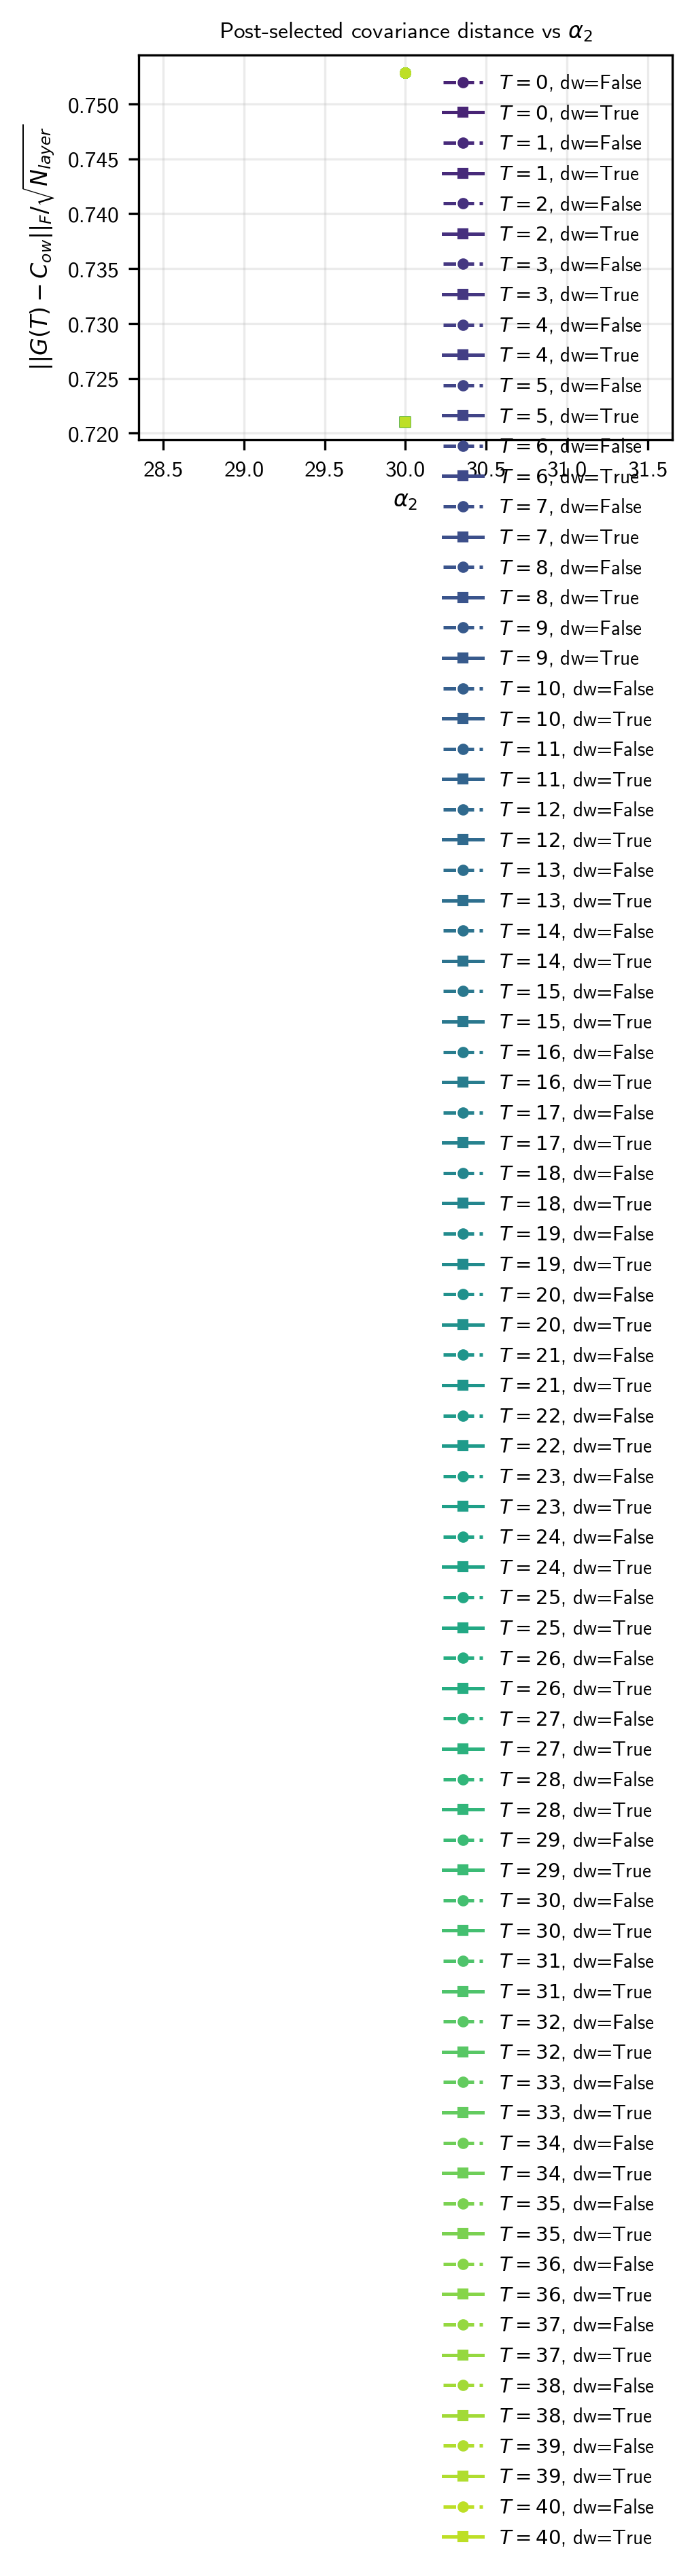

In [7]:
# ------------------------------
# Plot controls
# ------------------------------
PLOT_METRIC = "fro_norm_normalized"
PLOT_NSHELL_FILTER = None
PLOT_T_VALUES = T_VALUES
PLOT_DW_TRUNCATION_VALUES = DW_TRUNCATION_OPTIONS
FIGSIZE = (3.375, 2.45)
TITLE = r"Post-selected covariance distance vs $\alpha_2$"
XLABEL = r"$\alpha_2$"
YLABEL = selected_metric_label(PLOT_METRIC)
LEGEND_LOC = "best"
X_SCALE = "linear"
Y_SCALE = "linear"
X_LIMITS = None
Y_LIMITS = None
SAVE_THIS_FIGURE = False
FIGURE_NAME = "frobenius_vs_alpha2.png"

if summary_df.empty:
    display(Markdown("No rows available for the alpha_2 plot."))
else:
    plot_df = summary_df.copy()
    if PLOT_NSHELL_FILTER is not None:
        plot_df = plot_df[plot_df["nshell"].astype(str) == str(PLOT_NSHELL_FILTER)]
    plot_df = plot_df[plot_df["cycle_T"].isin([int(t) for t in PLOT_T_VALUES])]
    plot_df = plot_df[plot_df["dw_truncation"].isin([bool(v) for v in PLOT_DW_TRUNCATION_VALUES])]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    cycle_colors = plt.cm.viridis(np.linspace(0.1, 0.9, max(1, len(PLOT_T_VALUES))))
    for color, T in zip(cycle_colors, PLOT_T_VALUES):
        for dw_truncation in PLOT_DW_TRUNCATION_VALUES:
            group = plot_df[(plot_df["cycle_T"] == int(T)) & (plot_df["dw_truncation"] == bool(dw_truncation))]
            if group.empty:
                continue
            group = group.sort_values("alpha_2")
            linestyle = "-" if bool(dw_truncation) else "--"
            marker = "s" if bool(dw_truncation) else "o"
            ax.plot(
                group["alpha_2"],
                group[PLOT_METRIC],
                marker=marker,
                markersize=3.0,
                linestyle=linestyle,
                color=color,
                label=rf"$T={int(T)}$, dw={bool(dw_truncation)}",
            )
    ax.set_title(TITLE)
    ax.set_xlabel(XLABEL)
    ax.set_ylabel(YLABEL)
    ax.set_xscale(X_SCALE)
    ax.set_yscale(Y_SCALE)
    if X_LIMITS is not None:
        ax.set_xlim(*X_LIMITS)
    if Y_LIMITS is not None:
        ax.set_ylim(*Y_LIMITS)
    ax.legend(loc=LEGEND_LOC, frameon=False, ncol=1)
    fig.tight_layout()
    save_figure(fig, FIGURE_NAME, enabled=SAVE_THIS_FIGURE)
    plt.show()

## Figure: Heatmap Over Alpha and Cycle

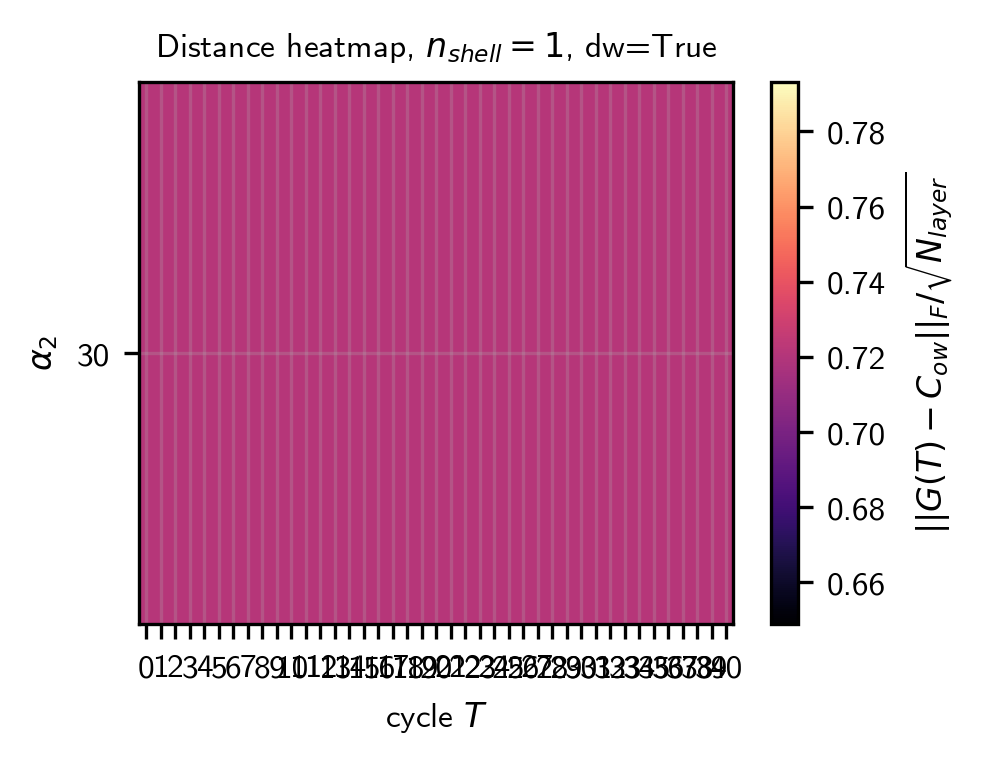

In [8]:
# ------------------------------
# Plot controls
# ------------------------------
PLOT_METRIC = "fro_norm_normalized"
HEATMAP_NSHELL = str(NSHELL_VALUES[0] if NSHELL_VALUES else "1")
HEATMAP_DW_TRUNCATION = bool(DW_TRUNCATION_OPTIONS[-1] if DW_TRUNCATION_OPTIONS else True)
FIGSIZE = (3.375, 2.65)
TITLE = rf"Distance heatmap, $n_{{shell}}={HEATMAP_NSHELL}$, dw={HEATMAP_DW_TRUNCATION}"
XLABEL = r"cycle $T$"
YLABEL = r"$\alpha_2$"
CMAP = "magma"
COLORBAR_LABEL = selected_metric_label(PLOT_METRIC)
SAVE_THIS_FIGURE = False
FIGURE_NAME = "frobenius_heatmap_alpha2_cycle.png"

if summary_df.empty:
    plot_df = pd.DataFrame()
else:
    plot_df = summary_df[
        (summary_df["nshell"].astype(str) == str(HEATMAP_NSHELL))
        & (summary_df["dw_truncation"] == bool(HEATMAP_DW_TRUNCATION))
    ].copy()

if plot_df.empty:
    display(Markdown("No rows match the heatmap controls."))
else:
    pivot = plot_df.pivot_table(index="alpha_2", columns="cycle_T", values=PLOT_METRIC, aggfunc="mean")
    pivot = pivot.sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    im = ax.imshow(np.asarray(pivot, dtype=float), origin="lower", aspect="auto", cmap=CMAP)
    ax.set_title(TITLE)
    ax.set_xlabel(XLABEL)
    ax.set_ylabel(YLABEL)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(int(v)) for v in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{float(v):g}" for v in pivot.index])
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(COLORBAR_LABEL)
    fig.tight_layout()
    save_figure(fig, FIGURE_NAME, enabled=SAVE_THIS_FIGURE)
    plt.show()

## Metadata Export

In [9]:
metadata = {
    "summary_stem": SUMMARY_STEM,
    "summary_csv": str(SUMMARY_CSV),
    "summary_pkl": str(SUMMARY_PKL),
    "summary_parquet": str(SUMMARY_PARQUET),
    "config": config,
    "canonical_dynamics_entry_point": CANONICAL_DYNAMICS_ENTRY_POINT,
    "created_unix": time.time(),
}
if SAVE_SUMMARY and not summary_df.empty:
    metadata_path = DATA_DIR / f"{SUMMARY_STEM}_metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2, sort_keys=True), encoding="utf-8")
    print(f"Saved metadata: {metadata_path}")
metadata

Saved metadata: /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/postselected_flattened_frobenius_N16x20_alpha2_30_nshell1_metadata.json


{'summary_stem': 'postselected_flattened_frobenius_N16x20_alpha2_30_nshell1',
 'summary_csv': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/postselected_flattened_frobenius_N16x20_alpha2_30_nshell1.csv',
 'summary_pkl': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/postselected_flattened_frobenius_N16x20_alpha2_30_nshell1.pkl',
 'summary_parquet': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/postselected_flattened_frobenius_N16x20_alpha2_30_nshell1.parquet',
 'config': {'Nx': 16,
  'Ny': 20,
  'N_layer': 640,
  'half_filling': 320,
  'DW': True,
  'alpha_1': 1.0,
  'alpha_2_values': [30.0],
  'nshell_values': [1],
  'dw_truncation_options': [False, True],
  'cycles': 40,
  'T_values': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   